# Titulo: Matrices de pesos espaciales.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [67]:
# Carga de modulos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
from libpysal.weights import Queen
from libpysal.weights import Rook
from shapely.geometry import LineString
from libpysal.weights import KNN
from libpysal.weights import DistanceBand

In [2]:
import libpysal
libpysal.__version__

'4.13.0'

In [3]:
# Configuración de google drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ruta completa del archivo

ruta = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/México_ent_22/00ent'

In [5]:
# Cargar mapa

Mapa = gpd.read_file(ruta + '.shp')
Mapa

Output hidden; open in https://colab.research.google.com to view.

## Matriz de pesos - Método de contigüidad : Reina

In [6]:
# Cálculo de matriz

W = Queen.from_dataframe(Mapa, ids = "CVE_ENT")

# Normalizar filas

W.transform = 'r'

In [7]:
W.neighbors

{'01': ['32', '14'],
 '02': ['03', '26'],
 '03': ['02'],
 '04': ['23', '27', '31'],
 '05': ['08', '10', '32', '19'],
 '06': ['14', '16'],
 '07': ['27', '20', '30'],
 '08': ['25', '10', '26', '05'],
 '09': ['15', '17'],
 '10': ['08', '25', '18', '05', '32'],
 '11': ['14', '16', '22', '24', '32'],
 '12': ['17', '15', '21', '16', '20'],
 '13': ['15', '21', '29', '22', '24', '30'],
 '14': ['18', '01', '11', '06', '16', '32'],
 '15': ['09', '21', '12', '29', '17', '13', '16', '22'],
 '16': ['15', '11', '14', '06', '22', '12'],
 '17': ['09', '15', '21', '12'],
 '18': ['25', '10', '32', '14'],
 '19': ['28', '24', '32', '05'],
 '20': ['30', '07', '21', '12'],
 '21': ['17', '15', '13', '12', '29', '20', '30'],
 '22': ['15', '11', '13', '16', '24'],
 '23': ['04', '31'],
 '24': ['11', '13', '28', '22', '32', '19', '30'],
 '25': ['08', '10', '18', '26'],
 '26': ['08', '02', '25'],
 '27': ['04', '07', '30'],
 '28': ['24', '19', '30'],
 '29': ['15', '13', '21'],
 '30': ['27', '13', '21', '28', '24',

In [8]:
# Visualizar contiguidad entre vecinos

## Vecinos de aguascalientes (CVE_ENT = 1)

print("Vecinos de la unidad 1 (0):")
print(W.neighbors['01'])

Vecinos de la unidad 1 (0):
['32', '14']


In [9]:
print("Vecinos de la unidad:")
print(W.neighbors['13'])

Vecinos de la unidad:
['15', '21', '29', '22', '24', '30']


In [10]:
# Visualizar pesos entre vecinos

## Vecinos de aguascalientes (CVE_ENT = 1)

print("Vecinos de la unidad 1:")
print(W.weights['01'])

Vecinos de la unidad 1:
[0.5, 0.5]


In [11]:
print("Vecinos de la unidad:")
print(W.weights['13'])

Vecinos de la unidad:
[0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]


In [12]:
# Matriz completa

W_dense, ids = W.full()

print("Dimensión de W:", W_dense.shape)
W_dense

Dimensión de W: (32, 32)


array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.5  ],
       [0.   , 0.   , 0.5  , ..., 0.   , 0.   , 0.   ],
       [0.   , 1.   , 0.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.125, 0.   , 0.   , ..., 0.   , 0.   , 0.   ]])

In [13]:
W_sparse = W.sparse

print(W_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 134 stored elements and shape (32, 32)>
  Coords	Values
  (0, 13)	0.5
  (0, 31)	0.5
  (1, 2)	0.5
  (1, 25)	0.5
  (2, 1)	1.0
  (3, 22)	0.3333333333333333
  (3, 26)	0.3333333333333333
  (3, 30)	0.3333333333333333
  (4, 7)	0.25
  (4, 9)	0.25
  (4, 18)	0.25
  (4, 31)	0.25
  (5, 13)	0.5
  (5, 15)	0.5
  (6, 19)	0.3333333333333333
  (6, 26)	0.3333333333333333
  (6, 29)	0.3333333333333333
  (7, 4)	0.25
  (7, 9)	0.25
  (7, 24)	0.25
  (7, 25)	0.25
  (8, 14)	0.5
  (8, 16)	0.5
  (9, 4)	0.2
  (9, 7)	0.2
  :	:
  (26, 6)	0.3333333333333333
  (26, 29)	0.3333333333333333
  (27, 18)	0.3333333333333333
  (27, 23)	0.3333333333333333
  (27, 29)	0.3333333333333333
  (28, 12)	0.3333333333333333
  (28, 14)	0.3333333333333333
  (28, 20)	0.3333333333333333
  (29, 6)	0.14285714285714285
  (29, 12)	0.14285714285714285
  (29, 19)	0.14285714285714285
  (29, 20)	0.14285714285714285
  (29, 23)	0.14285714285714285
  (29, 26)	0.14285714285714285
  (29, 27)	0

In [14]:
# Diagnóstico rápido

print("Número de observaciones:", W.n)
print("Islas (sin vecinos):", W.islands)
print("Componentes conectados:", W.n_components)

Número de observaciones: 32
Islas (sin vecinos): []
Componentes conectados: 1


/tmp/ipython-input-2593016565.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_queen = Queen.from_dataframe(Mapa)


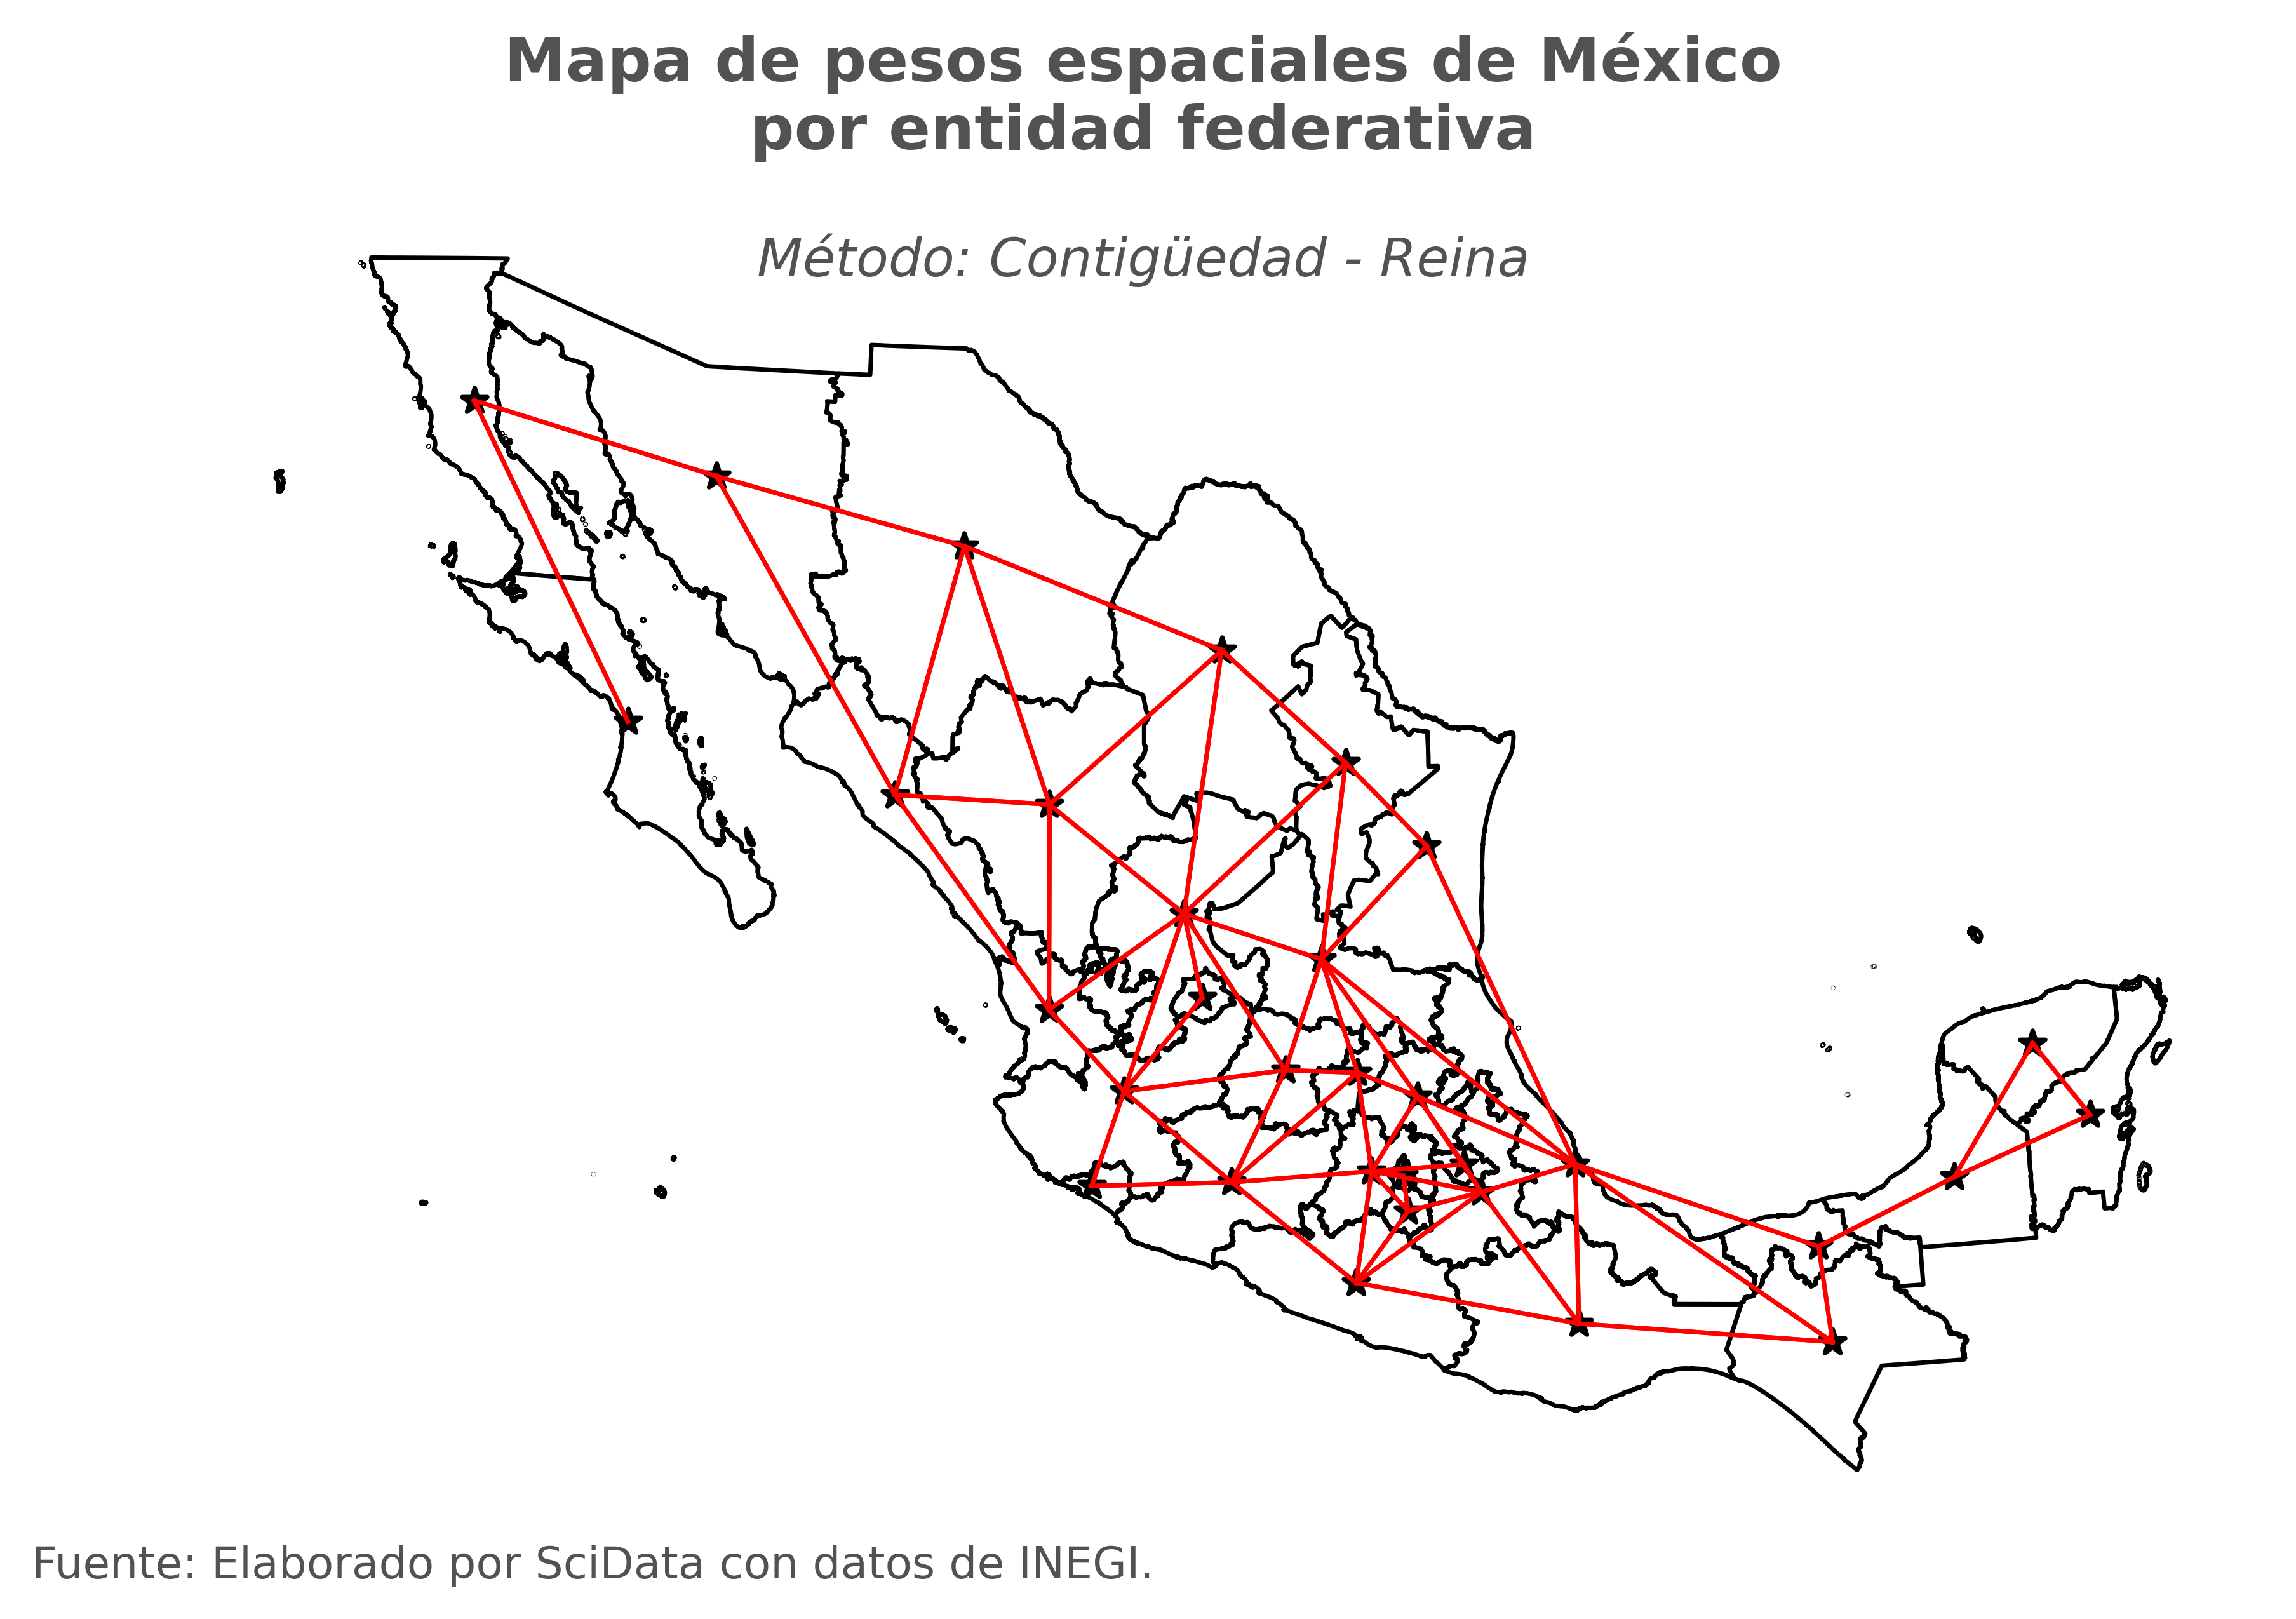

In [15]:
# Re calcular la matriz sin ids

W_queen = Queen.from_dataframe(Mapa)

# Normalizar filas

W_queen.transform = 'r'

## Visualización del mapa

fig, ax = plt.subplots(1,1, figsize = (10,5), dpi = 500)
#Poligonos
Mapa.plot(ax = ax,
          color = "white",
          edgecolor="black")
#Conexiones reina
W_queen.plot(
    Mapa,
    edge_kws = dict(linewidth = 1, color = "red"),
    node_kws = dict(marker = "*"),
    ax = ax
)
plt.figtext(0.4, 0.95, "Mapa de pesos espaciales de México\npor entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Método: Contigüedad - Reina",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaborado por SciData con datos de INEGI.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax.set_axis_off()
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Vecinos_Queen.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')


## Método de contigüedad de torre

In [27]:
# Cálculo de matriz

W = Rook.from_dataframe(Mapa, ids = "CVE_ENT")

# Normalizar filas

W.transform = 'r'

In [17]:
W.neighbors

{'01': ['32', '14'],
 '02': ['03', '26'],
 '03': ['02'],
 '04': ['23', '27', '31'],
 '05': ['08', '10', '32', '19'],
 '06': ['14', '16'],
 '07': ['27', '20', '30'],
 '08': ['25', '10', '26', '05'],
 '09': ['15', '17'],
 '10': ['08', '25', '18', '05', '32'],
 '11': ['14', '16', '22', '24', '32'],
 '12': ['17', '15', '21', '16', '20'],
 '13': ['15', '21', '29', '22', '24', '30'],
 '14': ['18', '01', '11', '06', '16', '32'],
 '15': ['09', '21', '12', '29', '17', '13', '16', '22'],
 '16': ['15', '11', '14', '06', '22', '12'],
 '17': ['09', '15', '21', '12'],
 '18': ['25', '10', '32', '14'],
 '19': ['28', '24', '32', '05'],
 '20': ['30', '07', '21', '12'],
 '21': ['17', '15', '13', '12', '29', '20', '30'],
 '22': ['15', '11', '13', '16', '24'],
 '23': ['04', '31'],
 '24': ['11', '13', '28', '22', '32', '19', '30'],
 '25': ['08', '10', '18', '26'],
 '26': ['08', '02', '25'],
 '27': ['04', '07', '30'],
 '28': ['24', '19', '30'],
 '29': ['15', '13', '21'],
 '30': ['27', '13', '21', '28', '24',

In [28]:
# Visualizar contiguidad entre vecinos

## Vecinos de aguascalientes (CVE_ENT = 1)

print("Vecinos de la unidad 1 (0):")
print(W.neighbors['01'])

Vecinos de la unidad 1 (0):
['32', '14']


In [19]:
print("Vecinos de la unidad:")
print(W.neighbors['13'])

Vecinos de la unidad:
['15', '21', '29', '22', '24', '30']


In [20]:
# Visualizar pesos entre vecinos

## Vecinos de aguascalientes (CVE_ENT = 1)

print("Vecinos de la unidad 1:")
print(W.weights['01'])

Vecinos de la unidad 1:
[0.5, 0.5]


In [21]:
print("Vecinos de la unidad:")
print(W.weights['13'])

Vecinos de la unidad:
[0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]


In [22]:
# Matriz completa

W_dense, ids = W.full()

print("Dimensión de W:", W_dense.shape)
W_dense

Dimensión de W: (32, 32)


array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.5  ],
       [0.   , 0.   , 0.5  , ..., 0.   , 0.   , 0.   ],
       [0.   , 1.   , 0.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.125, 0.   , 0.   , ..., 0.   , 0.   , 0.   ]])

In [23]:
W_sparse = W.sparse

print(W_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 134 stored elements and shape (32, 32)>
  Coords	Values
  (0, 13)	0.5
  (0, 31)	0.5
  (1, 2)	0.5
  (1, 25)	0.5
  (2, 1)	1.0
  (3, 22)	0.3333333333333333
  (3, 26)	0.3333333333333333
  (3, 30)	0.3333333333333333
  (4, 7)	0.25
  (4, 9)	0.25
  (4, 18)	0.25
  (4, 31)	0.25
  (5, 13)	0.5
  (5, 15)	0.5
  (6, 19)	0.3333333333333333
  (6, 26)	0.3333333333333333
  (6, 29)	0.3333333333333333
  (7, 4)	0.25
  (7, 9)	0.25
  (7, 24)	0.25
  (7, 25)	0.25
  (8, 14)	0.5
  (8, 16)	0.5
  (9, 4)	0.2
  (9, 7)	0.2
  :	:
  (26, 6)	0.3333333333333333
  (26, 29)	0.3333333333333333
  (27, 18)	0.3333333333333333
  (27, 23)	0.3333333333333333
  (27, 29)	0.3333333333333333
  (28, 12)	0.3333333333333333
  (28, 14)	0.3333333333333333
  (28, 20)	0.3333333333333333
  (29, 6)	0.14285714285714285
  (29, 12)	0.14285714285714285
  (29, 19)	0.14285714285714285
  (29, 20)	0.14285714285714285
  (29, 23)	0.14285714285714285
  (29, 26)	0.14285714285714285
  (29, 27)	0

In [24]:
# Diagnóstico rápido

print("Número de observaciones:", W.n)
print("Islas (sin vecinos):", W.islands)
print("Componentes conectados:", W.n_components)

Número de observaciones: 32
Islas (sin vecinos): []
Componentes conectados: 1


/tmp/ipython-input-2312170813.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_rook = Rook.from_dataframe(Mapa)


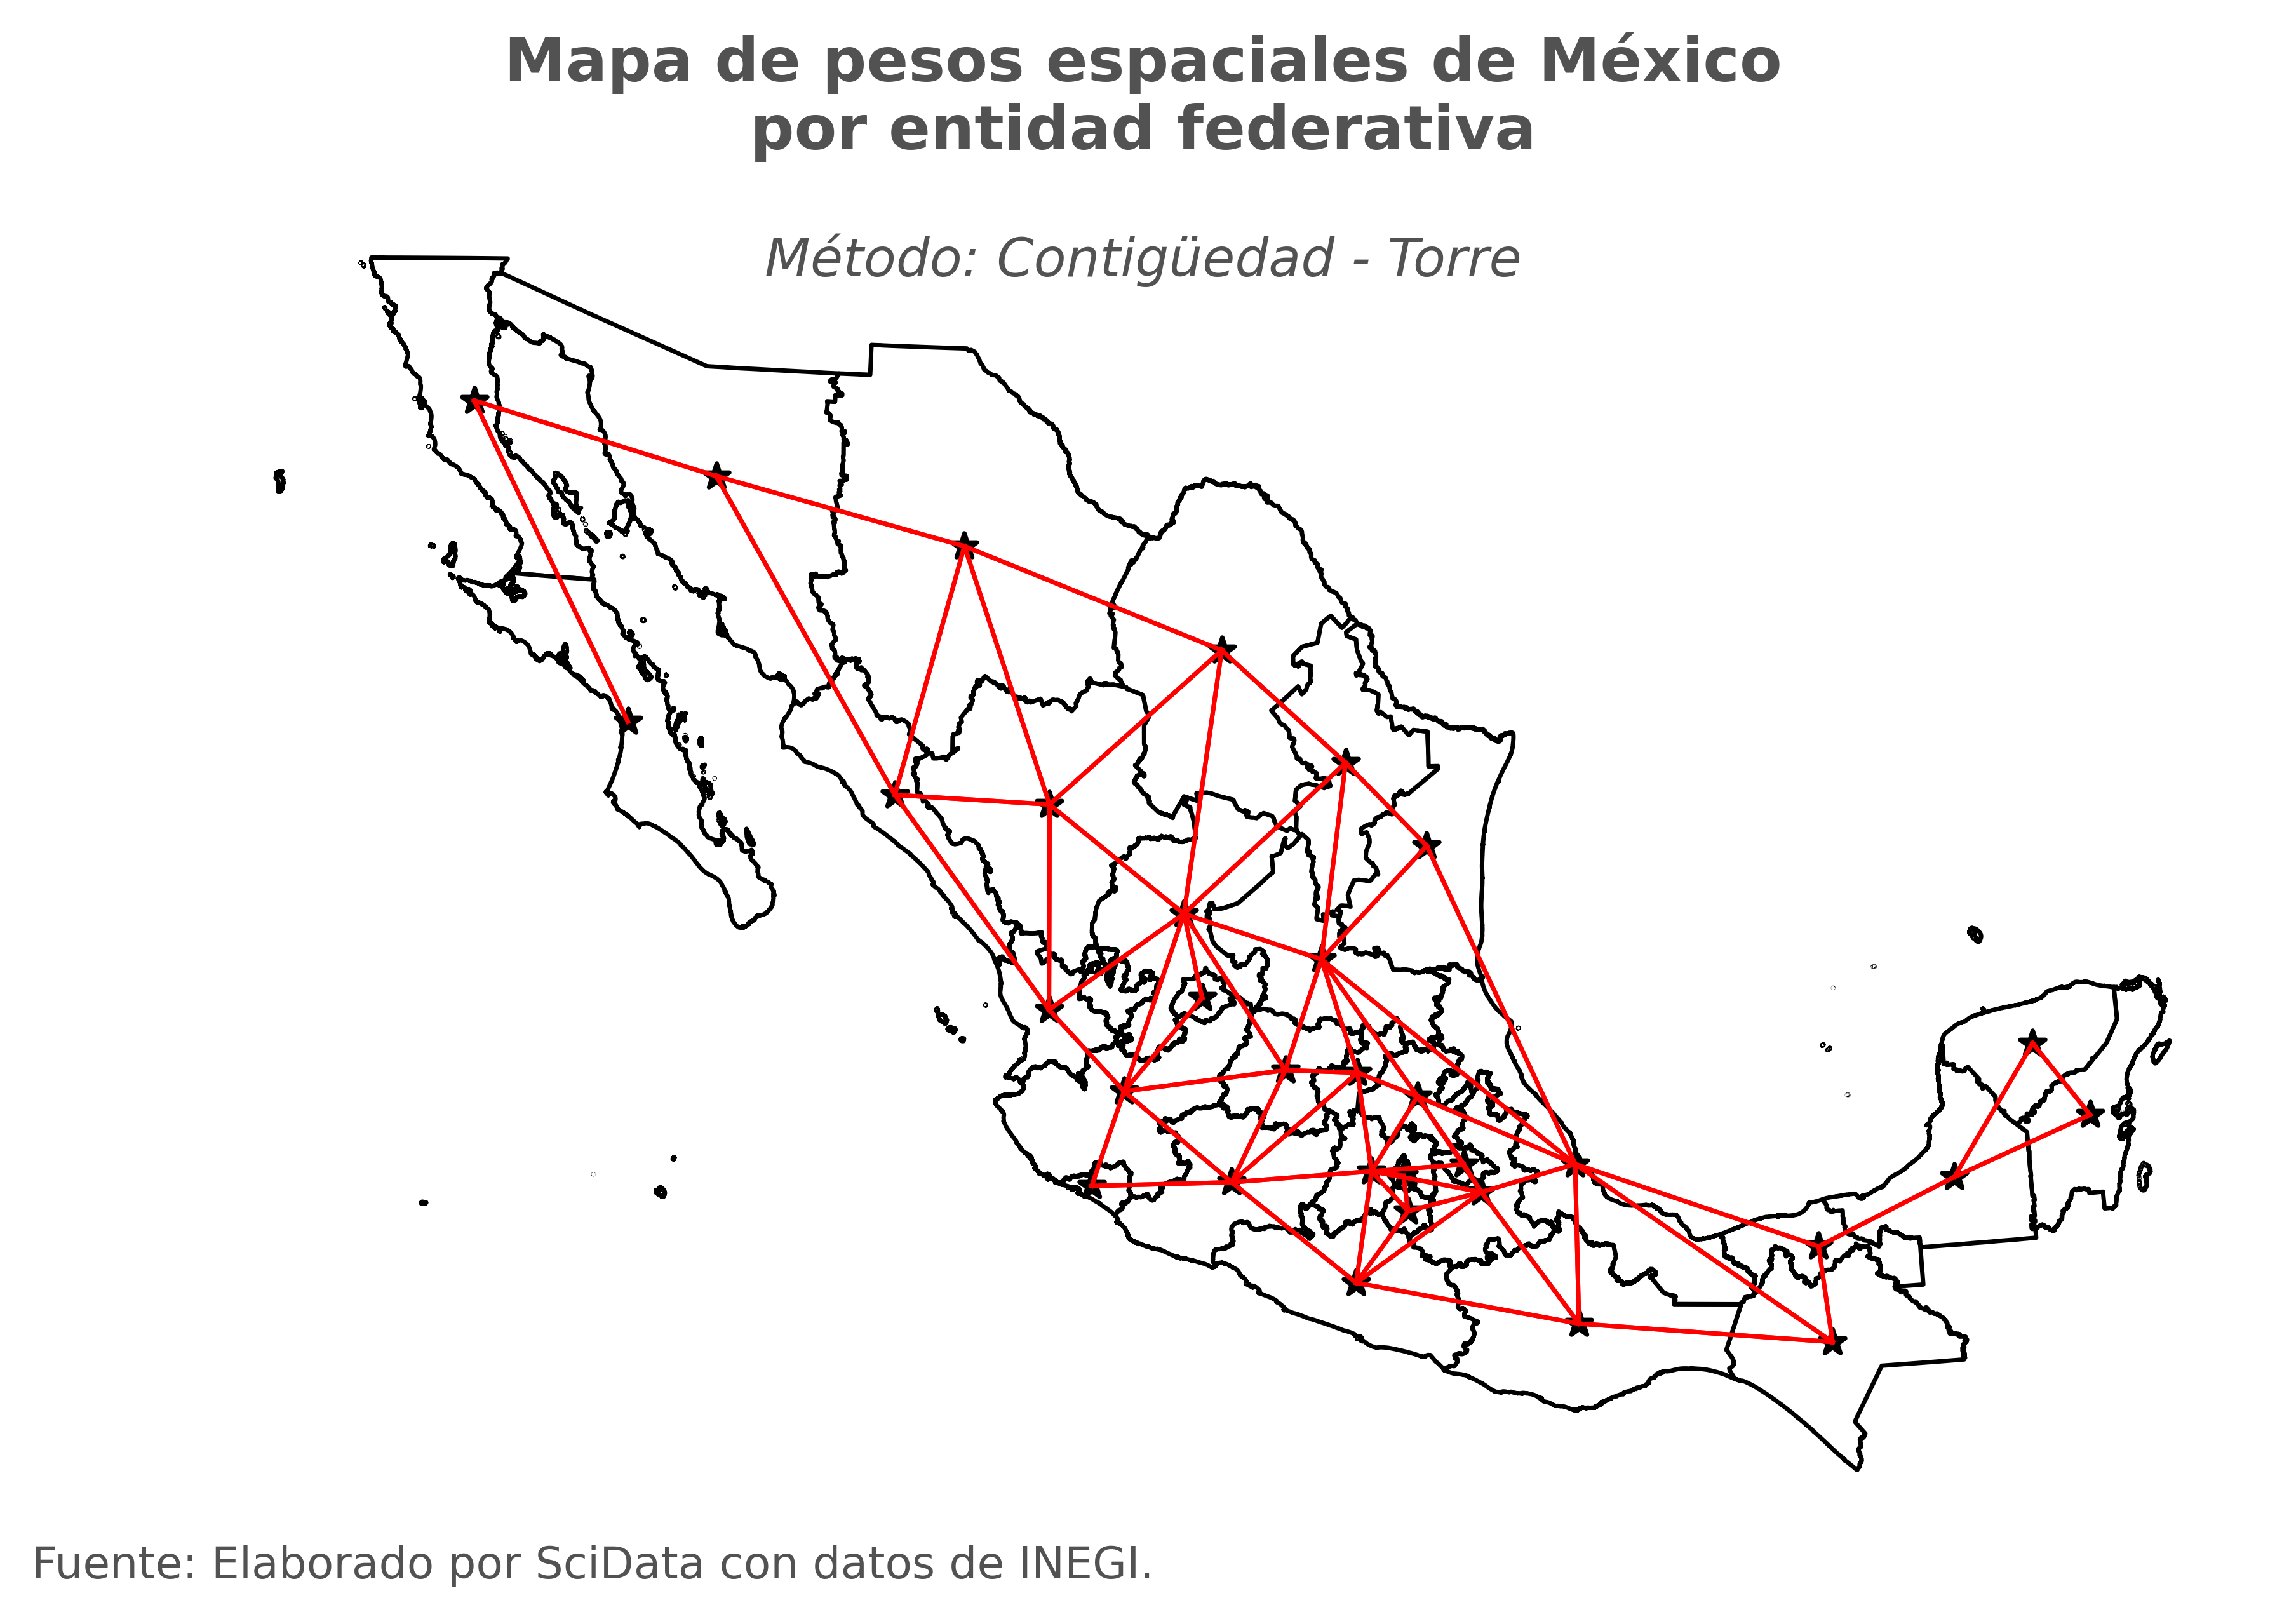

In [29]:
# Re calcular la matriz sin ids

W_rook = Rook.from_dataframe(Mapa)

# Normalizar filas

W_rook.transform = 'r'

## Visualización del mapa

fig, ax = plt.subplots(1,1, figsize = (10,5), dpi = 500)
#Poligonos
Mapa.plot(ax = ax,
          color = "white",
          edgecolor="black")
#Conexiones reina
W_rook.plot(
    Mapa,
    edge_kws = dict(linewidth = 1, color = "red"),
    node_kws = dict(marker = "*"),
    ax = ax
)
plt.figtext(0.4, 0.95, "Mapa de pesos espaciales de México\npor entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Método: Contigüedad - Torre",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaborado por SciData con datos de INEGI.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax.set_axis_off()
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Vecinos_Rook.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

## Método de vecinos - K vecinos

In [44]:
## Cálculo de la matriz con 4 vecinos por área

knn4 = KNN.from_dataframe(Mapa, k = 4, ids = "CVE_ENT")

# Normalizar filas

knn4.transform = 'r'

In [45]:
## Vecinos por área, polígono o entidades federativa

knn4.neighbors

{'01': [np.str_('32'), np.str_('11'), np.str_('14'), np.str_('24')],
 '02': [np.str_('26'), np.str_('03'), np.str_('08'), np.str_('25')],
 '03': [np.str_('26'), np.str_('25'), np.str_('02'), np.str_('08')],
 '04': [np.str_('23'), np.str_('27'), np.str_('31'), np.str_('07')],
 '05': [np.str_('19'), np.str_('10'), np.str_('32'), np.str_('08')],
 '06': [np.str_('14'), np.str_('16'), np.str_('18'), np.str_('01')],
 '07': [np.str_('27'), np.str_('04'), np.str_('20'), np.str_('30')],
 '08': [np.str_('26'), np.str_('25'), np.str_('10'), np.str_('05')],
 '09': [np.str_('15'), np.str_('17'), np.str_('29'), np.str_('21')],
 '10': [np.str_('25'), np.str_('32'), np.str_('18'), np.str_('05')],
 '11': [np.str_('22'), np.str_('01'), np.str_('24'), np.str_('16')],
 '12': [np.str_('17'), np.str_('15'), np.str_('09'), np.str_('21')],
 '13': [np.str_('22'), np.str_('09'), np.str_('29'), np.str_('15')],
 '14': [np.str_('06'), np.str_('18'), np.str_('01'), np.str_('16')],
 '15': [np.str_('09'), np.str_('17

In [46]:
## Contiguedades o vecinos de un área

print("Vecinos de la unidad 1 (01):")
print(knn4.neighbors['01'])

Vecinos de la unidad 1 (01):
[np.str_('32'), np.str_('11'), np.str_('14'), np.str_('24')]


In [47]:
print("Vecinos de la unidad 1 (01):")
print(knn4.neighbors['15'])

Vecinos de la unidad 1 (01):
[np.str_('09'), np.str_('17'), np.str_('13'), np.str_('29')]


In [48]:
# Visualizar pesos entre vecinos

## Vecinos de aguascalientes (CVE_ENT = 1)

print("Vecinos de la unidad 1:")
print(knn4.weights['01'])

Vecinos de la unidad 1:
[0.25, 0.25, 0.25, 0.25]


In [49]:
print("Vecinos de la unidad 9:")
print(knn4.weights['09'])

Vecinos de la unidad 9:
[0.25, 0.25, 0.25, 0.25]


In [50]:
# Matriz completa

knn4_dense, ids = knn4.full()

print("Dimensión de W:", knn4_dense.shape)
knn4_dense

Dimensión de W: (32, 32)


array([[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.25],
       [0.  , 0.  , 0.25, ..., 0.  , 0.  , 0.  ],
       [0.  , 0.25, 0.  , ..., 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.25, 0.  , 0.  , ..., 0.  , 0.  , 0.  ]])

In [51]:
knn4_sparse = knn4.sparse

print(knn4_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128 stored elements and shape (32, 32)>
  Coords	Values
  (0, 10)	0.25
  (0, 13)	0.25
  (0, 23)	0.25
  (0, 31)	0.25
  (1, 2)	0.25
  (1, 7)	0.25
  (1, 24)	0.25
  (1, 25)	0.25
  (2, 1)	0.25
  (2, 7)	0.25
  (2, 24)	0.25
  (2, 25)	0.25
  (3, 6)	0.25
  (3, 22)	0.25
  (3, 26)	0.25
  (3, 30)	0.25
  (4, 7)	0.25
  (4, 9)	0.25
  (4, 18)	0.25
  (4, 31)	0.25
  (5, 0)	0.25
  (5, 13)	0.25
  (5, 15)	0.25
  (5, 17)	0.25
  (6, 3)	0.25
  :	:
  (25, 24)	0.25
  (26, 3)	0.25
  (26, 6)	0.25
  (26, 19)	0.25
  (26, 29)	0.25
  (27, 12)	0.25
  (27, 18)	0.25
  (27, 21)	0.25
  (27, 23)	0.25
  (28, 8)	0.25
  (28, 12)	0.25
  (28, 16)	0.25
  (28, 20)	0.25
  (29, 12)	0.25
  (29, 19)	0.25
  (29, 20)	0.25
  (29, 28)	0.25
  (30, 3)	0.25
  (30, 6)	0.25
  (30, 22)	0.25
  (30, 26)	0.25
  (31, 0)	0.25
  (31, 9)	0.25
  (31, 17)	0.25
  (31, 23)	0.25


In [52]:
# Diagnóstico rápido

print("Número de observaciones:", knn4.n)
print("Islas (sin vecinos):", knn4.islands)
print("Componentes conectados:", knn4.n_components)

Número de observaciones: 32
Islas (sin vecinos): []
Componentes conectados: 1


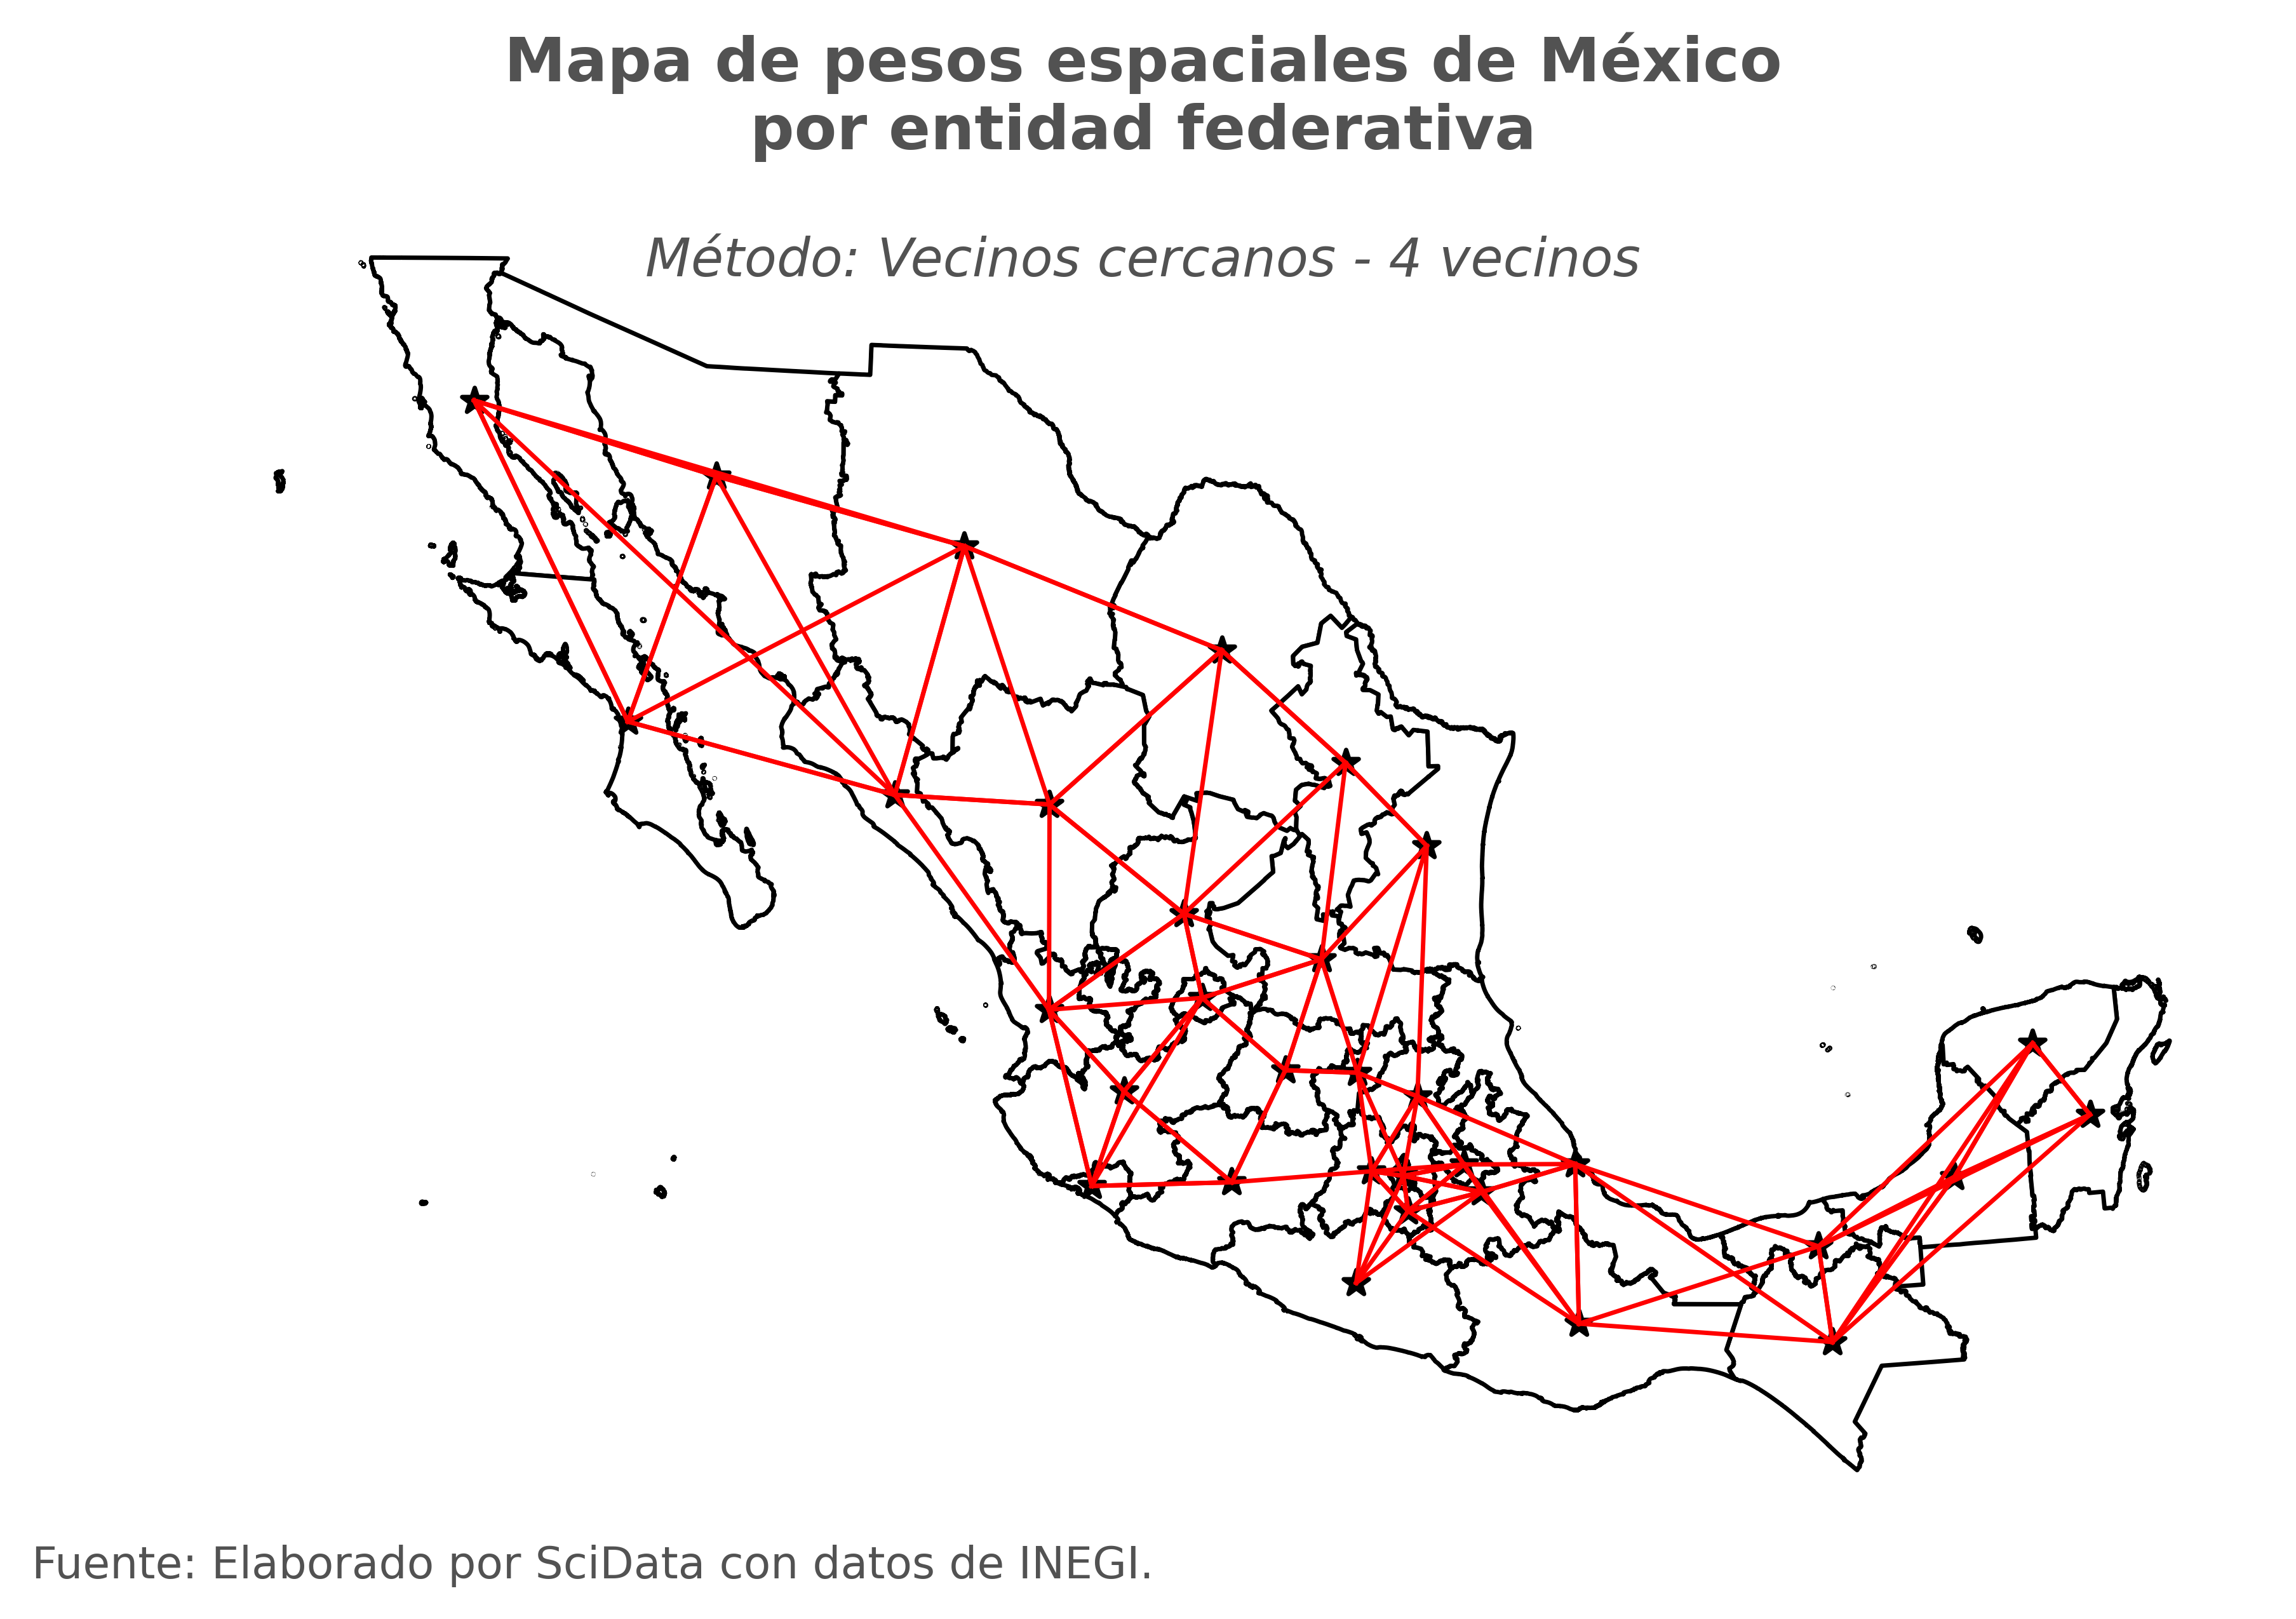

In [54]:
# Re calcular la matriz sin ids

W_knn4 = KNN.from_dataframe(Mapa, k=4)

# Normalizar filas

W_knn4.transform = 'r'

## Visualización del mapa

fig, ax = plt.subplots(1,1, figsize = (10,5), dpi = 500)
#Poligonos
Mapa.plot(ax = ax,
          color = "white",
          edgecolor="black")
#Conexiones reina
W_knn4.plot(
    Mapa,
    edge_kws = dict(linewidth = 1, color = "red"),
    node_kws = dict(marker = "*"),
    ax = ax
)
plt.figtext(0.4, 0.95, "Mapa de pesos espaciales de México\npor entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Método: Vecinos cercanos - 4 vecinos",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaborado por SciData con datos de INEGI.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax.set_axis_off()
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Vecinos_4k.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')

### ¿Serán las 4 distancias más cortas las que elije KKN?

In [55]:
Mapa['centroid'] = Mapa.geometry.centroid
Mapa

Output hidden; open in https://colab.research.google.com to view.

In [56]:
centroides = Mapa[['CVE_ENT', 'centroid']].copy()

In [59]:
distancias = []

for i, row_i in centroides.iterrows():
  for j, row_j in centroides.iterrows():
    dist = row_i['centroid'].distance(row_j['centroid'])
    distancias.append({
        "id_origen": row_i['CVE_ENT'],
        "id_destino": row_j['CVE_ENT'],
        "distancia_metros": dist
    })

distancias_df = pd.DataFrame(distancias)
distancias_df

,id_origen,id_destino,distancia_metros
0,01,01,0.000000e+00
1,01,02,1.576978e+06
2,01,03,1.067158e+06
3,01,04,1.294955e+06
4,01,05,5.830032e+05
...,...,...,...
1019,32,28,4.222990e+05
1020,32,29,6.292483e+05
1021,32,30,7.777402e+05
1022,32,31,1.437691e+06


In [68]:
## 4 distancias más cortas de aguascalientes

(
    distancias_df
    .query("id_origen == '01'")
    .sort_values("distancia_metros", ascending = True)
    .reset_index(drop = True)
).head(5)

,id_origen,id_destino,distancia_metros
0,01,01,0.000000
1,01,32,144094.626609
2,01,11,184662.671890
3,01,14,203923.470711
4,01,24,209939.936708


## Matriz de inversa de la distancia

In [74]:
# Cálculo de matriz inversa de la distancia

W_D_inv = DistanceBand.from_dataframe(
    Mapa,
    threshold= 9000000,
    binary = False,
    p = 2,
    alpha = -2.0,
    ids = "CVE_ENT"
)

W_D_inv.transform = "r"

In [75]:
## Vecinos por área, polígono o entidades federativa

W_D_inv.neighbors

{'01': ['02',
  '03',
  '04',
  '05',
  '06',
  '07',
  '08',
  '09',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29',
  '30',
  '31',
  '32'],
 '02': ['01',
  '03',
  '04',
  '05',
  '06',
  '07',
  '08',
  '09',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29',
  '30',
  '31',
  '32'],
 '03': ['01',
  '02',
  '04',
  '05',
  '06',
  '07',
  '08',
  '09',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29',
  '30',
  '31',
  '32'],
 '04': ['01',
  '02',
  '03',
  '05',
  '06',
  '07',
  '08',
  '09',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29',
  '30

In [76]:
## Contiguedades o vecinos de un área

print("Vecinos de la unidad 1 (01):")
print(W_D_inv.neighbors['01'])


Vecinos de la unidad 1 (01):
['02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32']


In [77]:
# Visualizar pesos entre vecinos

## Vecinos de aguascalientes (CVE_ENT = 1)

print("Vecinos de la unidad 1:")
print(W_D_inv.weights['01'])

Vecinos de la unidad 1:
[0.0017359621316043918, 0.003790827103031965, 0.0025744370347963734, 0.012701344696086117, 0.032367767879301935, 0.002984488892486704, 0.005909888017545581, 0.021327472721757983, 0.025373618407959427, 0.12659989184362713, 0.014668971448963869, 0.027455874499687474, 0.10381428966127357, 0.026193925246503474, 0.04413326062453892, 0.01751836122450193, 0.06527386463424632, 0.020299246231146317, 0.006203961290842459, 0.013305385763617027, 0.051747251037262174, 0.0019196516150303859, 0.09794932353083417, 0.011351952268675376, 0.003028848924544914, 0.0034845487782036804, 0.020917593611770445, 0.015992694669549487, 0.00923025724975166, 0.0022251699420858875, 0.20791986901877288]


In [78]:
# Matriz completa

W_D_inv_dense, ids = W_D_inv.full()

print("Dimensión de W:", W_D_inv_dense.shape)
W_D_inv_dense

Dimensión de W: (32, 32)


array([[0.        , 0.00173596, 0.00379083, ..., 0.00923026, 0.00222517,
        0.20791987],
       [0.0213069 , 0.        , 0.14910225, ..., 0.01052502, 0.00664843,
        0.0246268 ],
       [0.02799348, 0.08970714, 0.        , ..., 0.01039935, 0.00547372,
        0.03284169],
       ...,
       [0.01202483, 0.00111714, 0.00183463, ..., 0.        , 0.00895907,
        0.00929796],
       [0.00632365, 0.00153937, 0.00210652, ..., 0.0195435 , 0.        ,
        0.00593561],
       [0.27148399, 0.00261985, 0.00580699, ..., 0.00931903, 0.00272715,
        0.        ]])

In [79]:
W_D_inv_sparse = W_D_inv.sparse

print(W_D_inv_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 992 stored elements and shape (32, 32)>
  Coords	Values
  (0, 1)	0.0017359621316043918
  (0, 2)	0.003790827103031965
  (0, 3)	0.0025744370347963734
  (0, 4)	0.012701344696086117
  (0, 5)	0.032367767879301935
  (0, 6)	0.002984488892486704
  (0, 7)	0.005909888017545581
  (0, 8)	0.021327472721757983
  (0, 9)	0.025373618407959427
  (0, 10)	0.12659989184362713
  (0, 11)	0.014668971448963869
  (0, 12)	0.027455874499687474
  (0, 13)	0.10381428966127357
  (0, 14)	0.026193925246503474
  (0, 15)	0.04413326062453892
  (0, 16)	0.01751836122450193
  (0, 17)	0.06527386463424632
  (0, 18)	0.020299246231146317
  (0, 19)	0.006203961290842459
  (0, 20)	0.013305385763617027
  (0, 21)	0.051747251037262174
  (0, 22)	0.0019196516150303859
  (0, 23)	0.09794932353083417
  (0, 24)	0.011351952268675376
  (0, 25)	0.003028848924544914
  :	:
  (31, 6)	0.003327834079955462
  (31, 7)	0.010967473240333678
  (31, 8)	0.017203997386892968
  (31, 9)	0.06700296

In [80]:
# Diagnóstico rápido

print("Número de observaciones:", W_D_inv.n)
print("Islas (sin vecinos):", W_D_inv.islands)
print("Componentes conectados:", W_D_inv.n_components)

Número de observaciones: 32
Islas (sin vecinos): []
Componentes conectados: 1


/usr/local/lib/python3.12/dist-packages/scipy/sparse/_data.py:128: RuntimeWarning: divide by zero encountered in power
  return self._with_data(data ** n)


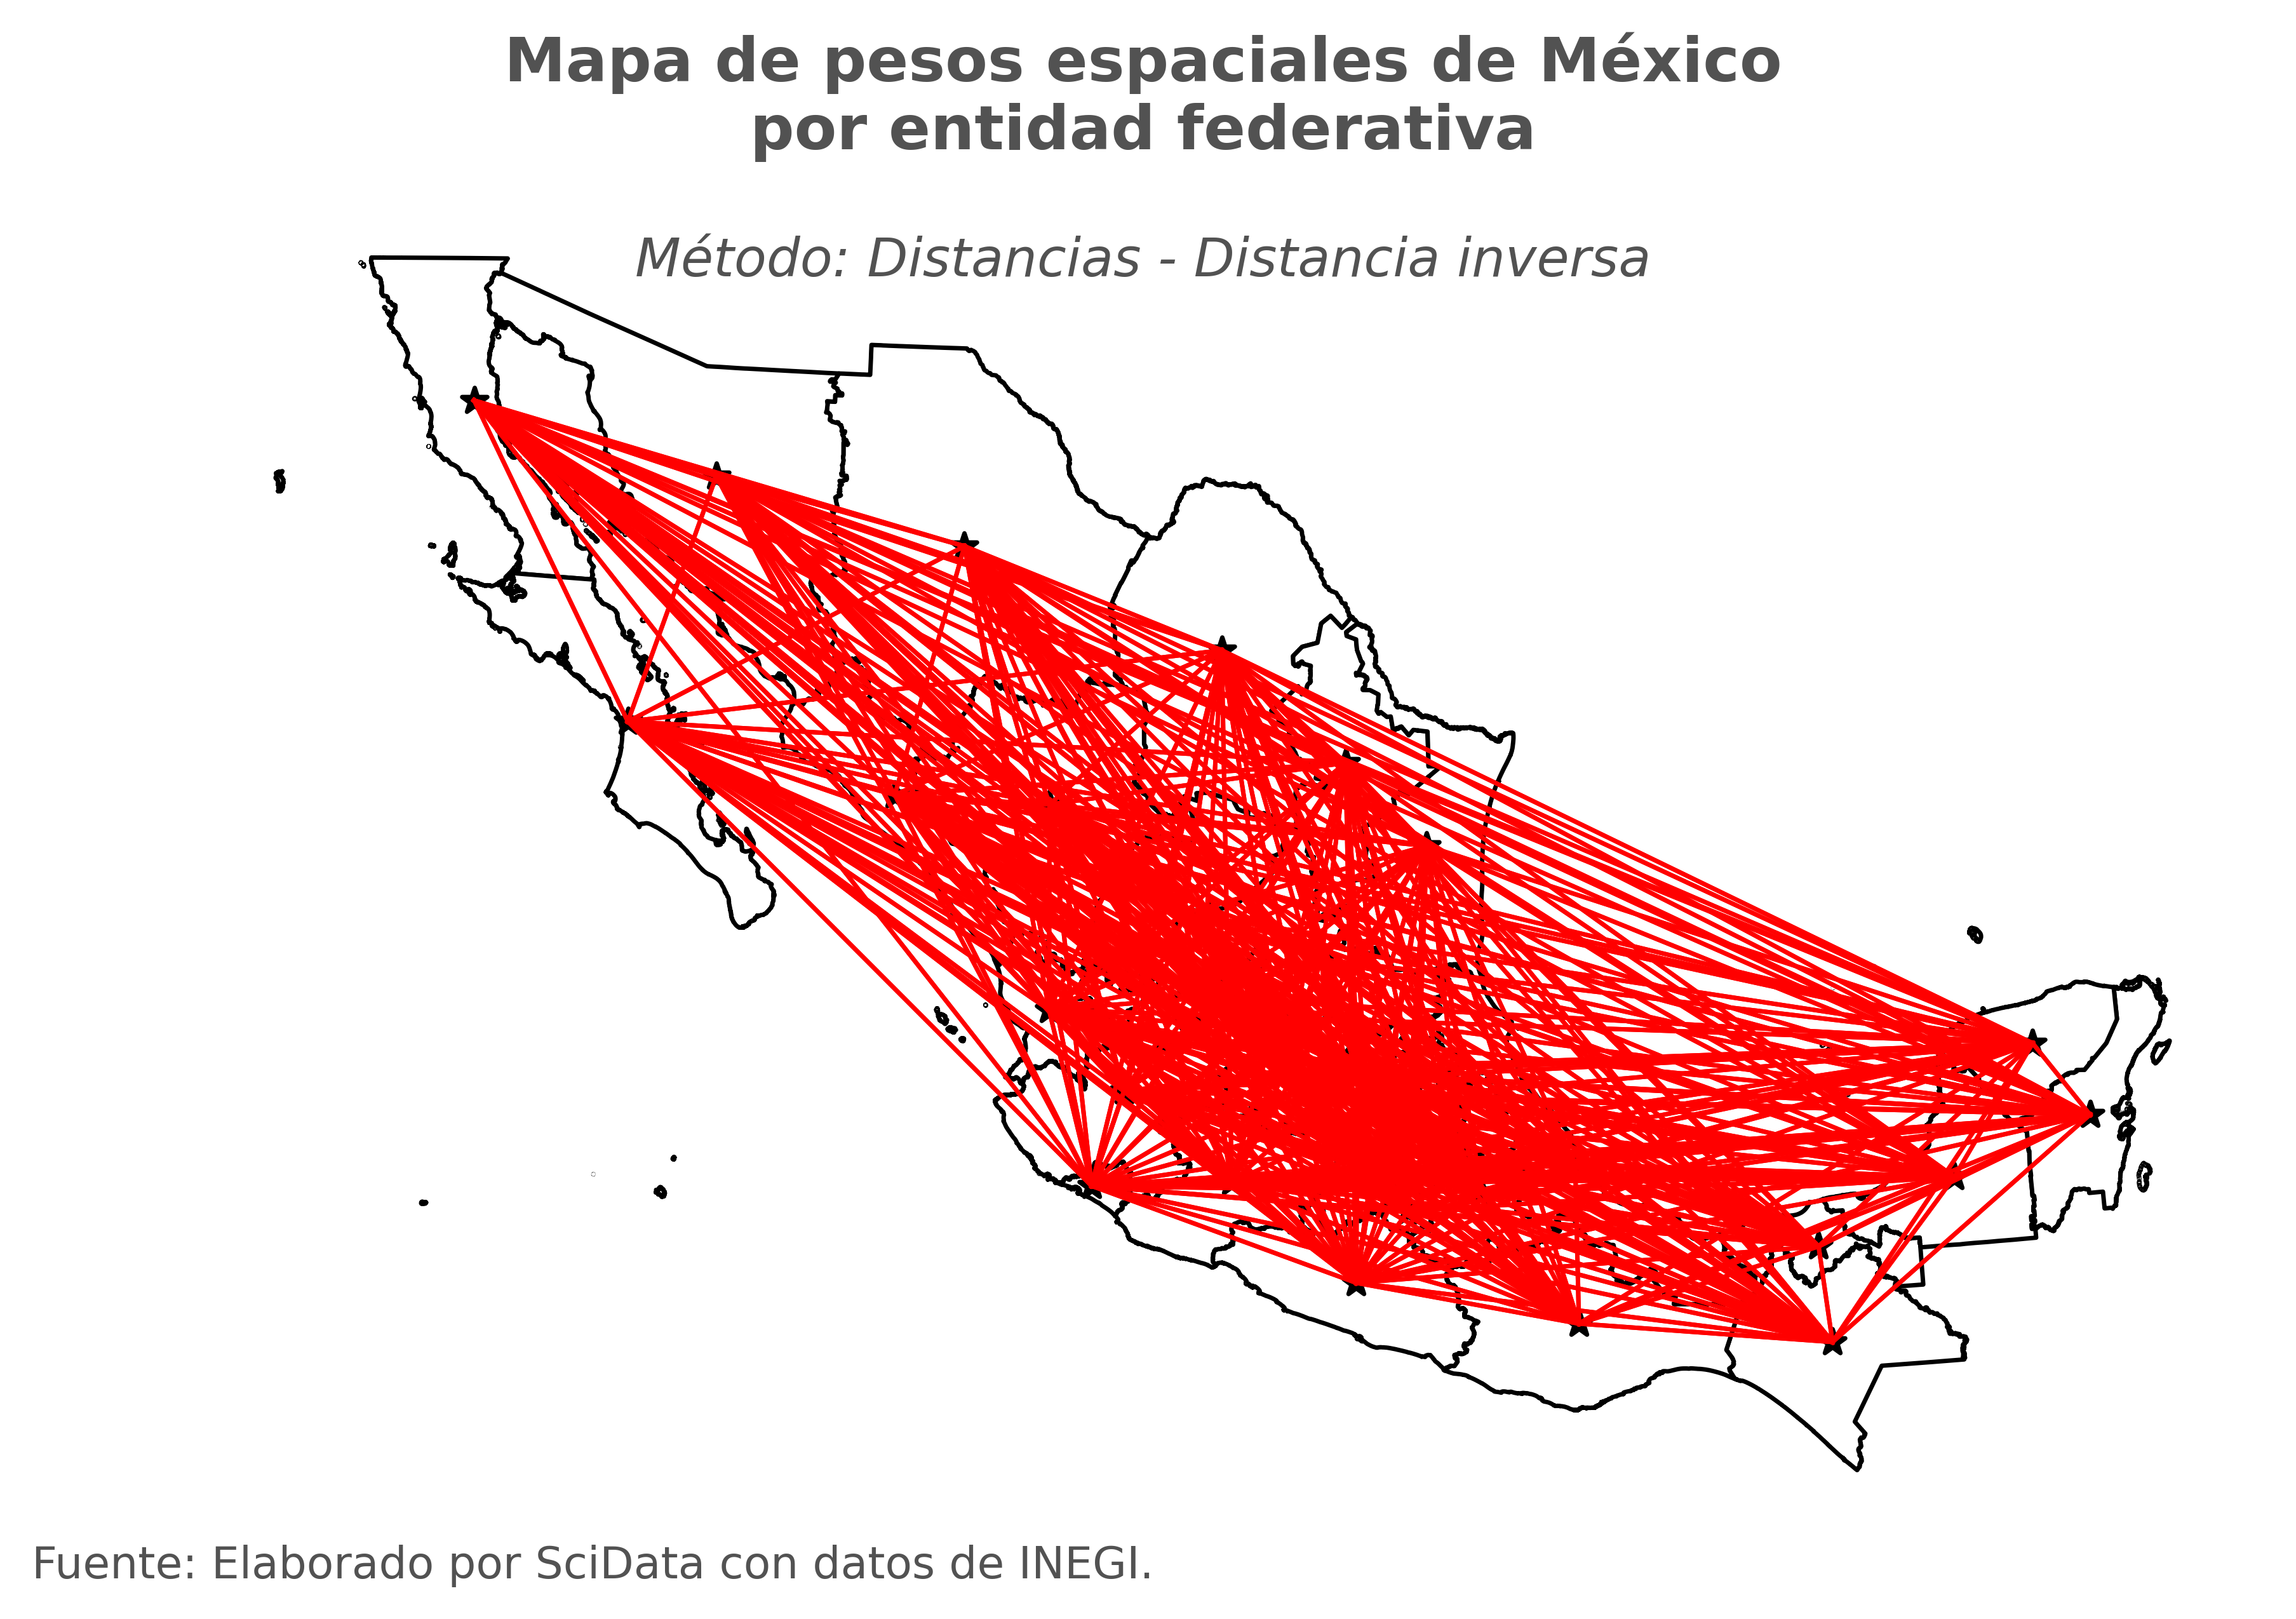

In [81]:
# Re calcular la matriz sin ids

W_D_inv2 = DistanceBand.from_dataframe(
    Mapa,
    threshold= 9000000,
    binary = False,
    p = 2,
    alpha = -2.0
)

# Normalizar filas

W_D_inv2.transform = 'r'

## Visualización del mapa

fig, ax = plt.subplots(1,1, figsize = (10,5), dpi = 500)
#Poligonos
Mapa.plot(ax = ax,
          color = "white",
          edgecolor="black")
#Conexiones reina
W_D_inv2.plot(
    Mapa,
    edge_kws = dict(linewidth = 1, color = "red"),
    node_kws = dict(marker = "*"),
    ax = ax
)
plt.figtext(0.4, 0.95, "Mapa de pesos espaciales de México\npor entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.87, "Método: Distancias - Distancia inversa",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: Elaborado por SciData con datos de INEGI.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax.set_axis_off()
ax = plt.gca()
plt.grid(False)
plt.tight_layout(rect = [0,0.05,0.85,0.95])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Vecinos_distancia_inversa.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')
